# Analisis Perilaku Pelanggan E-Commerce: Deteksi Pelanggan Potensial menggunakan EDA di Python

**Studi Kasus:** E-Commerce Customer Analytics
**Tujuan:** Menganalisis perilaku belanja pelanggan pada platform toko online untuk mendeteksi pelanggan potensial (high value customer), sehingga tim bisnis dapat menyusun strategi retensi dan promosi yang lebih tepat sasaran.

**Dataset:** `mhs1_ecommerce_analytics.csv` — data transaksi pelanggan yang mencakup umur, kota domisili, kategori produk favorit, total belanja, dan status pembelian ulang.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('mhs1_ecommerce_analytics.csv')

df_awal = df.copy()

print(f"Shape dataset awal: {df_awal.shape}")
print("\nInformasi Dataset")
df_awal.info()


## 1. Identifikasi Masalah & Struktur Data

Sebelum masuk ke analisis, kita perlu memahami tipe data dari tiap kolom.

| Kolom | Tipe Data Python | Karakteristik Statistik |
|---|---|---|
| ID_Pelanggan | object | Nominal |
| Umur | float64 | Rasio |
| Kota | object | Nominal |
| Total_Belanja | int64 | Rasio |
| Kategori_Produk | object | Nominal |
| Membeli_Lagi | object | Nominal |

Kolom numerik (`Umur`, `Total_Belanja`) berskala **Rasio** karena memiliki titik nol mutlak yang bermakna (misalnya total belanja 0 berarti pelanggan tersebut benar-benar belum pernah bertransaksi). Sementara `ID_Pelanggan`, `Kota`, `Kategori_Produk`, dan `Membeli_Lagi` bersifat **Nominal** karena hanya berfungsi sebagai label/pengelompokan tanpa urutan tingkatan.

---


## 2. Statistik Deskriptif & Distribusi Awal

Cek ringkasan statistik sebelum data dibersihkan, khususnya pada kolom `Umur` yang masih memiliki nilai kosong.


In [ ]:
print("\n=== STATISTIK DESKRIPTIF ===")
print(df.describe())
print(f"\nMean Umur: {df['Umur'].mean():.2f}")
print(f"Median Umur: {df['Umur'].median():.2f}")

**Analisis kebijakan statistik:** Nilai mean `Total_Belanja` jauh lebih besar daripada mediannya, dengan skewness positif yang cukup tinggi. Ini menandakan distribusi total belanja pelanggan condong ke kanan (*right-skewed*) — mayoritas pelanggan berbelanja dalam jumlah menengah ke bawah, namun ada segelintir pelanggan dengan total belanja sangat besar yang menarik rata-rata ke atas. Dari sisi bisnis, pola ini mengindikasikan adanya kelompok kecil pelanggan bernilai tinggi (*high value customer*) yang berkontribusi tidak proporsional terhadap pendapatan — kelompok inilah yang menjadi target utama analisis "pelanggan potensial" di bagian selanjutnya.

Sementara itu, distribusi `Umur` relatif lebih simetris (skewness mendekati 0), menandakan sebaran usia pelanggan cukup merata di rentang dewasa muda hingga paruh baya.


## 3. Preprocessing & Transformasi Data

### 3.1 Penanganan Data Kosong

Kolom `Umur` memiliki beberapa baris kosong. Nilai kosong ini diasumsikan terjadi karena sebagian pelanggan tidak mengisi data umur saat proses registrasi akun, sehingga diisi dengan **median** (bukan dihapus) agar tidak sensitif terhadap outlier.


In [ ]:
print("\nMISSING VALUES SEBELUM CLEANING")
print(df.isnull().sum())

data_kosong = df[df.isnull().any(axis=1)].copy()


median_umur = df['Umur'].median()
df['Umur'] = df['Umur'].fillna(median_umur)

print(f"\nJumlah baris kosong sebelum: {data_kosong.shape[0]}")
print(f"Jumlah baris kosong sesudah : {df['Umur'].isnull().sum()}")
data_kosong[['ID_Pelanggan', 'Kota', 'Umur']].head()

**Justifikasi:** Jika baris dengan `Umur` kosong langsung dihapus (*drop rows*), perusahaan berisiko kehilangan informasi transaksi pelanggan tersebut, padahal total belanja dan kota mereka tetap valid dan berguna untuk analisis. Imputasi median lebih tepat karena median tidak mudah terpengaruh outlier usia, sehingga distribusi umur tetap representatif setelah data diperbaiki.

### 3.2 Penanganan Data Duplikat

Beberapa `ID_Pelanggan` tercatat lebih dari satu kali, kemungkinan karena sistem checkout mencatat transaksi pelanggan yang sama secara ganda. Baris duplikat disimpan terlebih dahulu untuk ditelusuri, lalu dihapus dengan mempertahankan kemunculan pertama.


In [ ]:
# Simpan data duplikat SEBELUM dihapus (urutan diperbaiki)
data_duplikat = df[df.duplicated(subset='ID_Pelanggan', keep=False)].copy()
print(f"\nJumlah data duplikat sebelum cleaning: {len(data_duplikat)}")

# Hapus data duplikat berdasarkan ID pelanggan
df = df.drop_duplicates(subset='ID_Pelanggan', keep='first')

print(f"Jumlah data setelah cleaning: {len(df)}")
print(f"Jumlah duplikat tersisa: {df.duplicated(subset='ID_Pelanggan').sum()}")


In [ ]:
data_duplikat[['ID_Pelanggan', 'Kota', 'Total_Belanja']]


### 3.3 Feature Engineering: Klasifikasi Status Pelanggan

Menggunakan `np.where()` untuk membuat kolom baru `Kategori_Status`: pelanggan dengan `Total_Belanja` > Rp5.000.000 diberi label **'Pelanggan Potensial'**, sisanya **'Pelanggan Biasa'**.


In [ ]:
df['Kategori_Status'] = np.where(
    df['Total_Belanja'] > 5000000,
    'Pelanggan Potensial',
    'Pelanggan Biasa'
)

df[['ID_Pelanggan', 'Umur', 'Kota', 'Total_Belanja', 'Kategori_Status']].head(8)

In [ ]:
df['Kategori_Status'].value_counts()

### 3.4 Analisis Retensi: Pembelian Ulang (`Membeli_Lagi`)

Kolom `Membeli_Lagi` menunjukkan apakah pelanggan pernah bertransaksi lebih dari satu kali. Bagian ini membandingkan proporsi pembelian ulang secara umum maupun antar kategori status pelanggan, untuk melihat apakah pelanggan potensial cenderung lebih loyal.


In [ ]:
print("\n=== DISTRIBUSI MEMBELI LAGI ===")
print(df['Membeli_Lagi'].value_counts())

print("\n=== MEMBELI LAGI vs KATEGORI STATUS PELANGGAN ===")
print(pd.crosstab(df['Kategori_Status'], df['Membeli_Lagi']))


Selanjutnya, dari seluruh pelanggan potensial, kita persempit fokus hanya pada pelanggan yang berdomisili di kota besar (**Jakarta** dan **Surabaya**) karena kedua kota ini merupakan pasar utama perusahaan.


In [ ]:
df_potensial = df[(df['Total_Belanja'] > 5000000) & 
                  (df['Kota'].isin(['Jakarta', 'Surabaya']))]
print(f"\nPELANGGAN POTENSIAL")
print(f"Total: {len(df_potensial)} pelanggan")
df_potensial[['ID_Pelanggan', 'Umur', 'Kota', 'Total_Belanja', 'Kategori_Produk']]

## 4. Data Storytelling & Rekomendasi Bisnis

Agregasi total pendapatan per kota untuk melihat kota mana yang paling berkontribusi terhadap pendapatan platform.


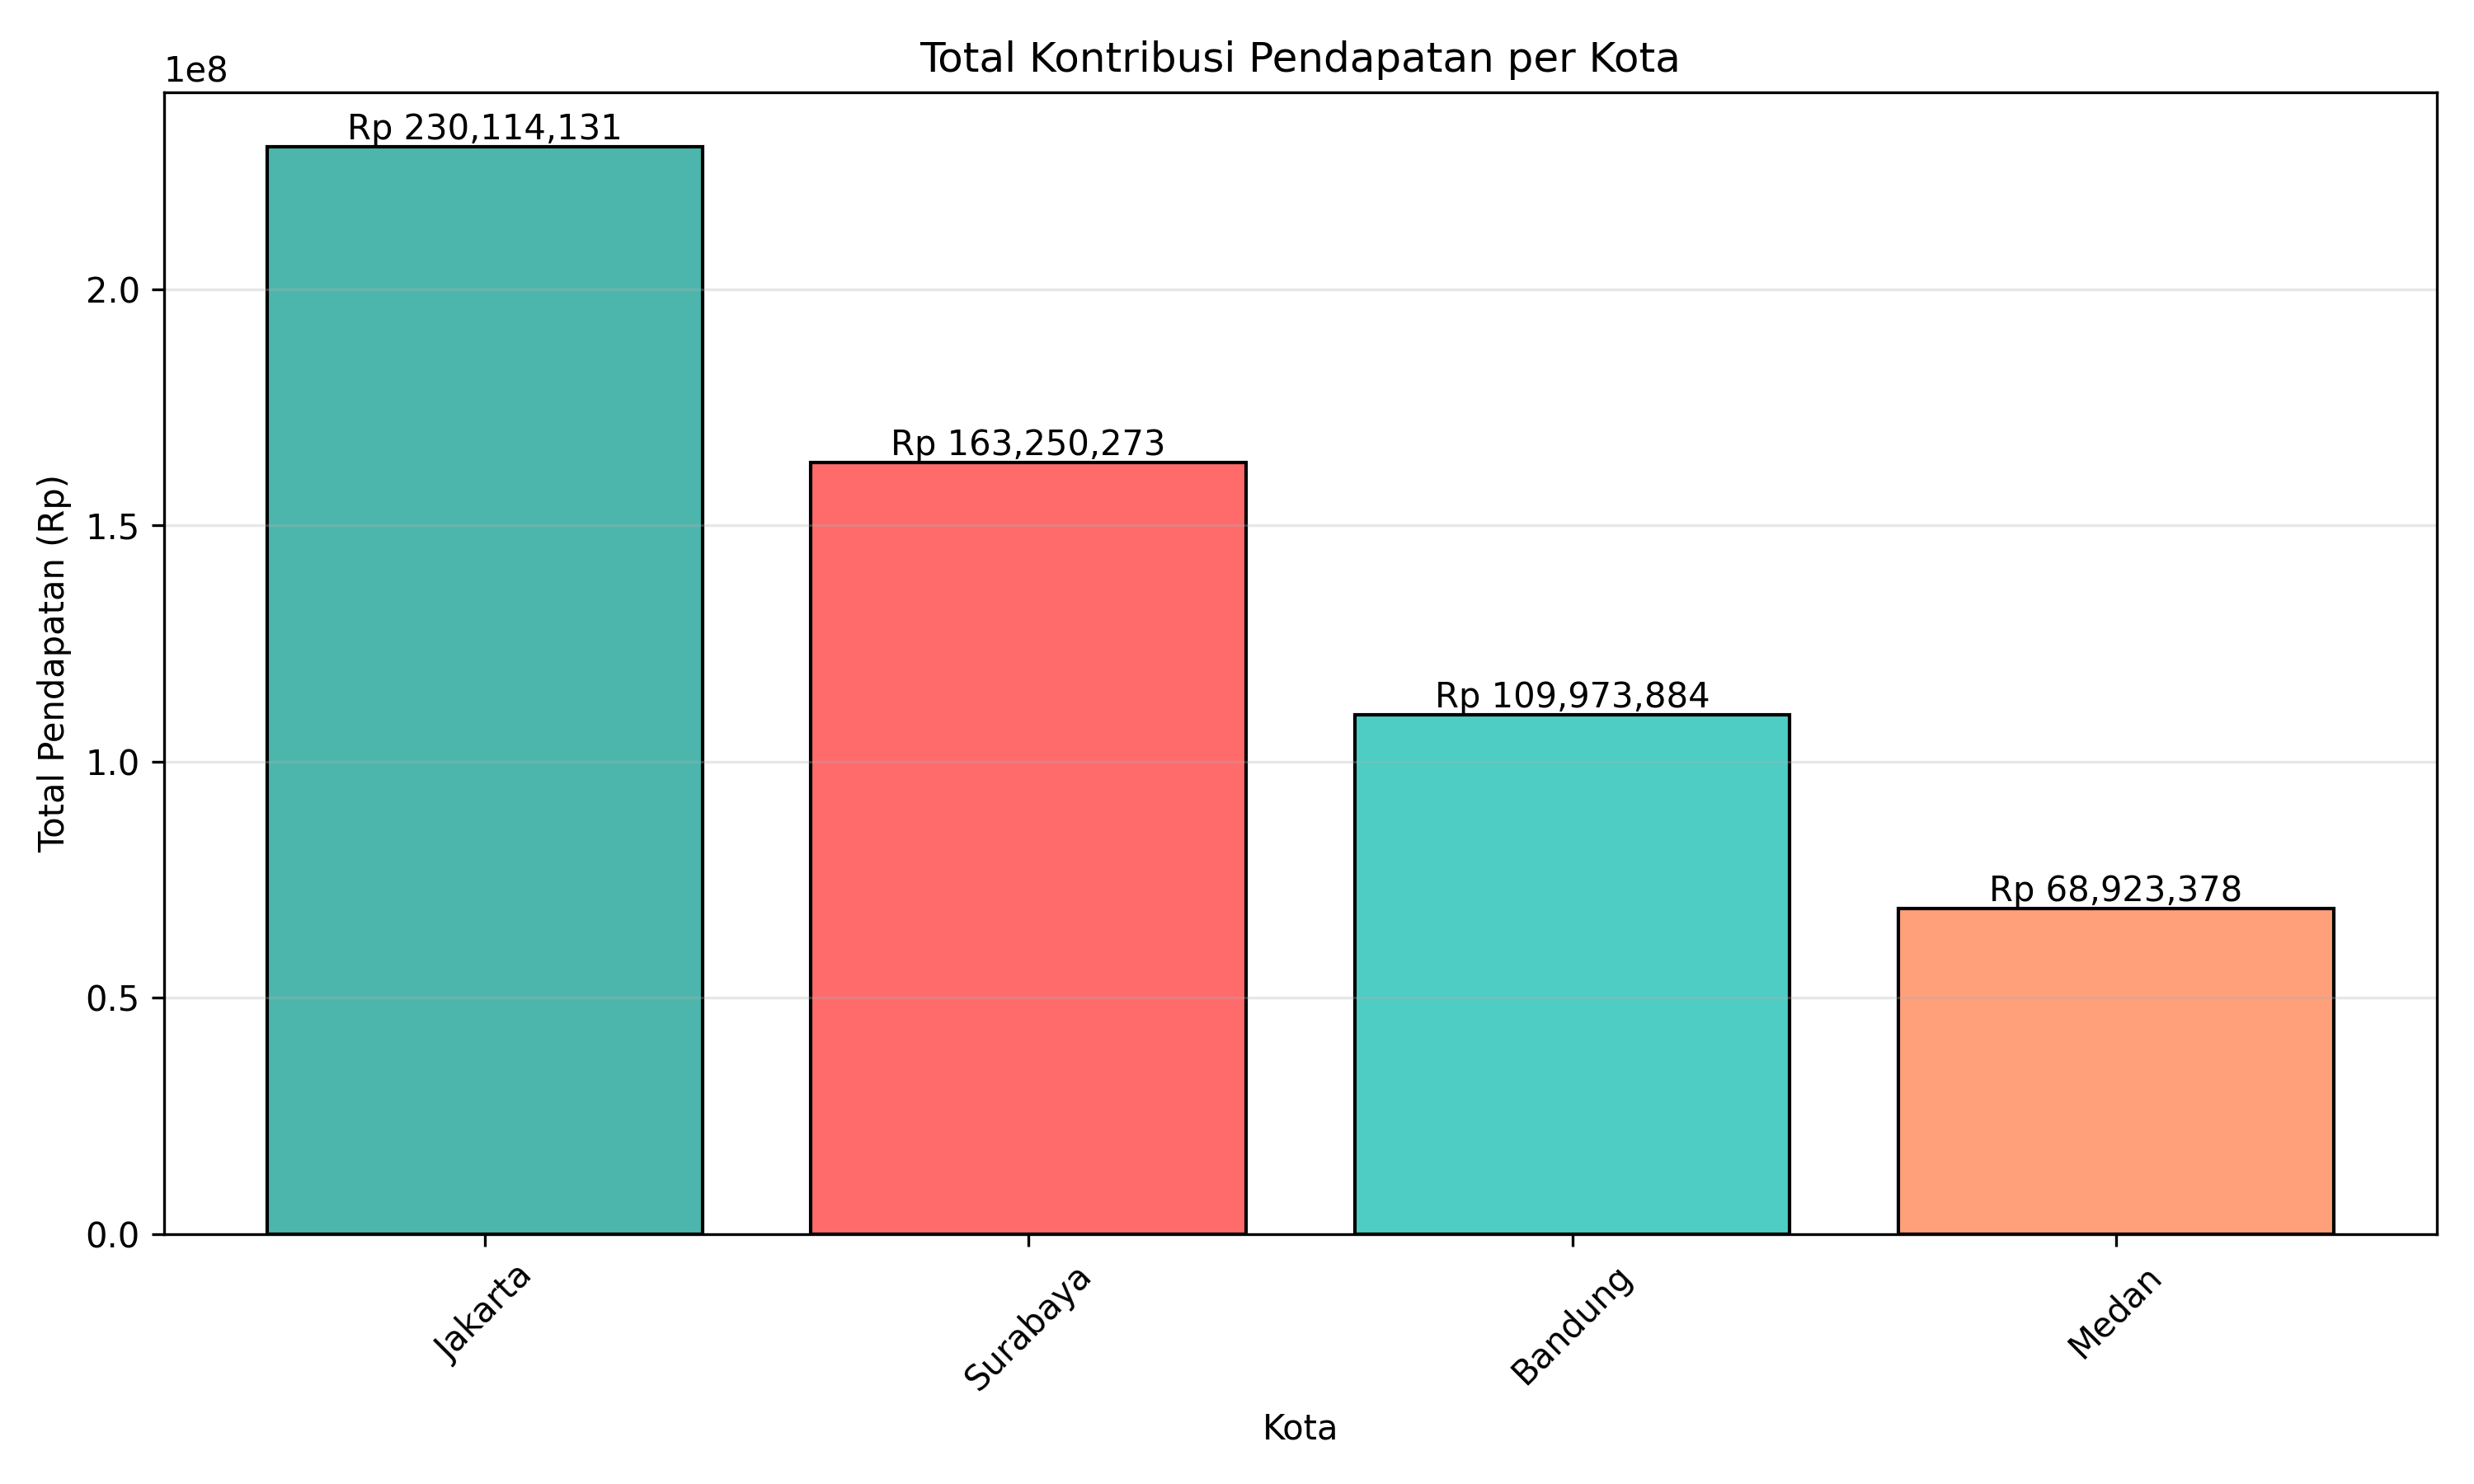

In [19]:
pendapatan_kota = (
    df.groupby('Kota')['Total_Belanja']
    .sum()
    .sort_values(ascending=False)
)

print("\n=== TOTAL PENDAPATAN PER KOTA ===")
print(pendapatan_kota)

plt.figure(figsize=(10,6))

bars = plt.bar(
    pendapatan_kota.index,
    pendapatan_kota.values,
    color=['#45B7D1', '#FF6B6B', '#4ECDC4', '#FFA07A'],
    edgecolor='black'
)

for bar in bars:
    nilai = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        nilai,
        f'Rp {nilai:,.0f}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.title('Total Kontribusi Pendapatan per Kota',
          fontsize=14,
          fontweight='bold')

plt.ylabel('Total Pendapatan (Rp)')
plt.xlabel('Kota')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.savefig('pendapatan_per_kota.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

## 5. Grafik Distribusi Awal (Sebelum Cleaning)

Visualisasi distribusi `Umur` dan `Total_Belanja` sebelum data dibersihkan, lengkap dengan garis mean dan median untuk melihat arah kemencengan (*skewness*) datanya.


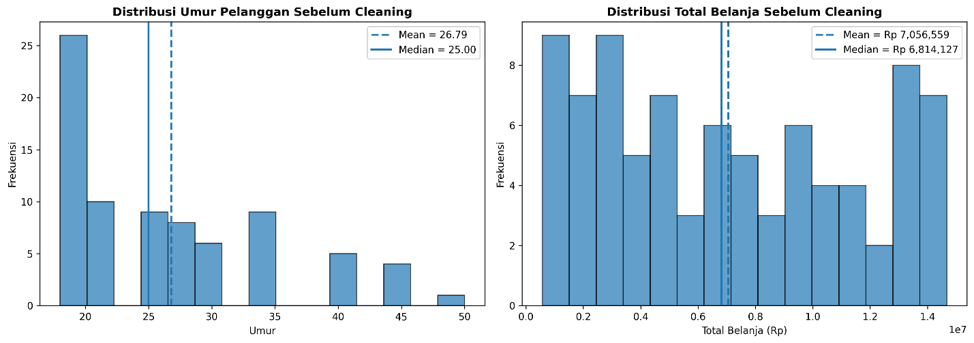

In [21]:
print("\n=== DISTRIBUSI DATA AWAL SEBELUM CLEANING ===")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


mean_umur_awal = df_awal['Umur'].mean()
median_umur_awal = df_awal['Umur'].median()

mean_belanja_awal = df_awal['Total_Belanja'].mean()
median_belanja_awal = df_awal['Total_Belanja'].median()


axes[0].hist(
    df_awal['Umur'].dropna(),
    bins=15,
    edgecolor='black',
    alpha=0.7
)

axes[0].axvline(
    mean_umur_awal,
    linestyle='--',
    linewidth=2,
    label=f'Mean = {mean_umur_awal:.2f}'
)

axes[0].axvline(
    median_umur_awal,
    linestyle='-',
    linewidth=2,
    label=f'Median = {median_umur_awal:.2f}'
)


axes[0].set_title(
    'Distribusi Umur Pelanggan Sebelum Cleaning',
    fontsize=12,
    fontweight='bold'
)

axes[0].set_xlabel('Umur')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()



axes[1].hist(
    df_awal['Total_Belanja'],
    bins=15,
    edgecolor='black',
    alpha=0.7
)

axes[1].axvline(
    mean_belanja_awal,
    linestyle='--',
    linewidth=2,
    label=f'Mean = Rp {mean_belanja_awal:,.0f}'
)

axes[1].axvline(
    median_belanja_awal,
    linestyle='-',
    linewidth=2,
    label=f'Median = Rp {median_belanja_awal:,.0f}'
)


axes[1].set_title(
    'Distribusi Total Belanja Sebelum Cleaning',
    fontsize=12,
    fontweight='bold'
)

axes[1].set_xlabel('Total Belanja (Rp)')
axes[1].set_ylabel('Frekuensi')
axes[1].legend()


plt.tight_layout()

plt.savefig(
    'distribusi_awal_sebelum_cleaning.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## 6. Export Hasil Cleaning ke Excel

Menyimpan data duplikat (untuk ditelusuri) dan data final hasil *cleaning* ke dalam satu file Excel dengan dua sheet berbeda.


In [ ]:
print("\n=== EXPORT DATA CLEANING ===")

data_clean_final = df.copy()

nama_file = "Data_Duplikat_dan_Data_Kosong_Diperbaiki.xlsx"

with pd.ExcelWriter(nama_file, engine='openpyxl') as writer:

    data_kosong.to_excel(writer, sheet_name="Data Kosong", index=False)

    data_duplikat.to_excel(writer, sheet_name="Data Duplikat", index=False)

    data_clean_final.to_excel(writer, sheet_name="Data Setelah Cleaning", index=False)

print(f"\nFile Excel berhasil dibuat: {nama_file}")


## 7. Distribusi Data Setelah Cleaning

Bandingkan sebaran `Umur` dan `Total_Belanja` setelah data kosong diimputasi dan duplikat dihapus.


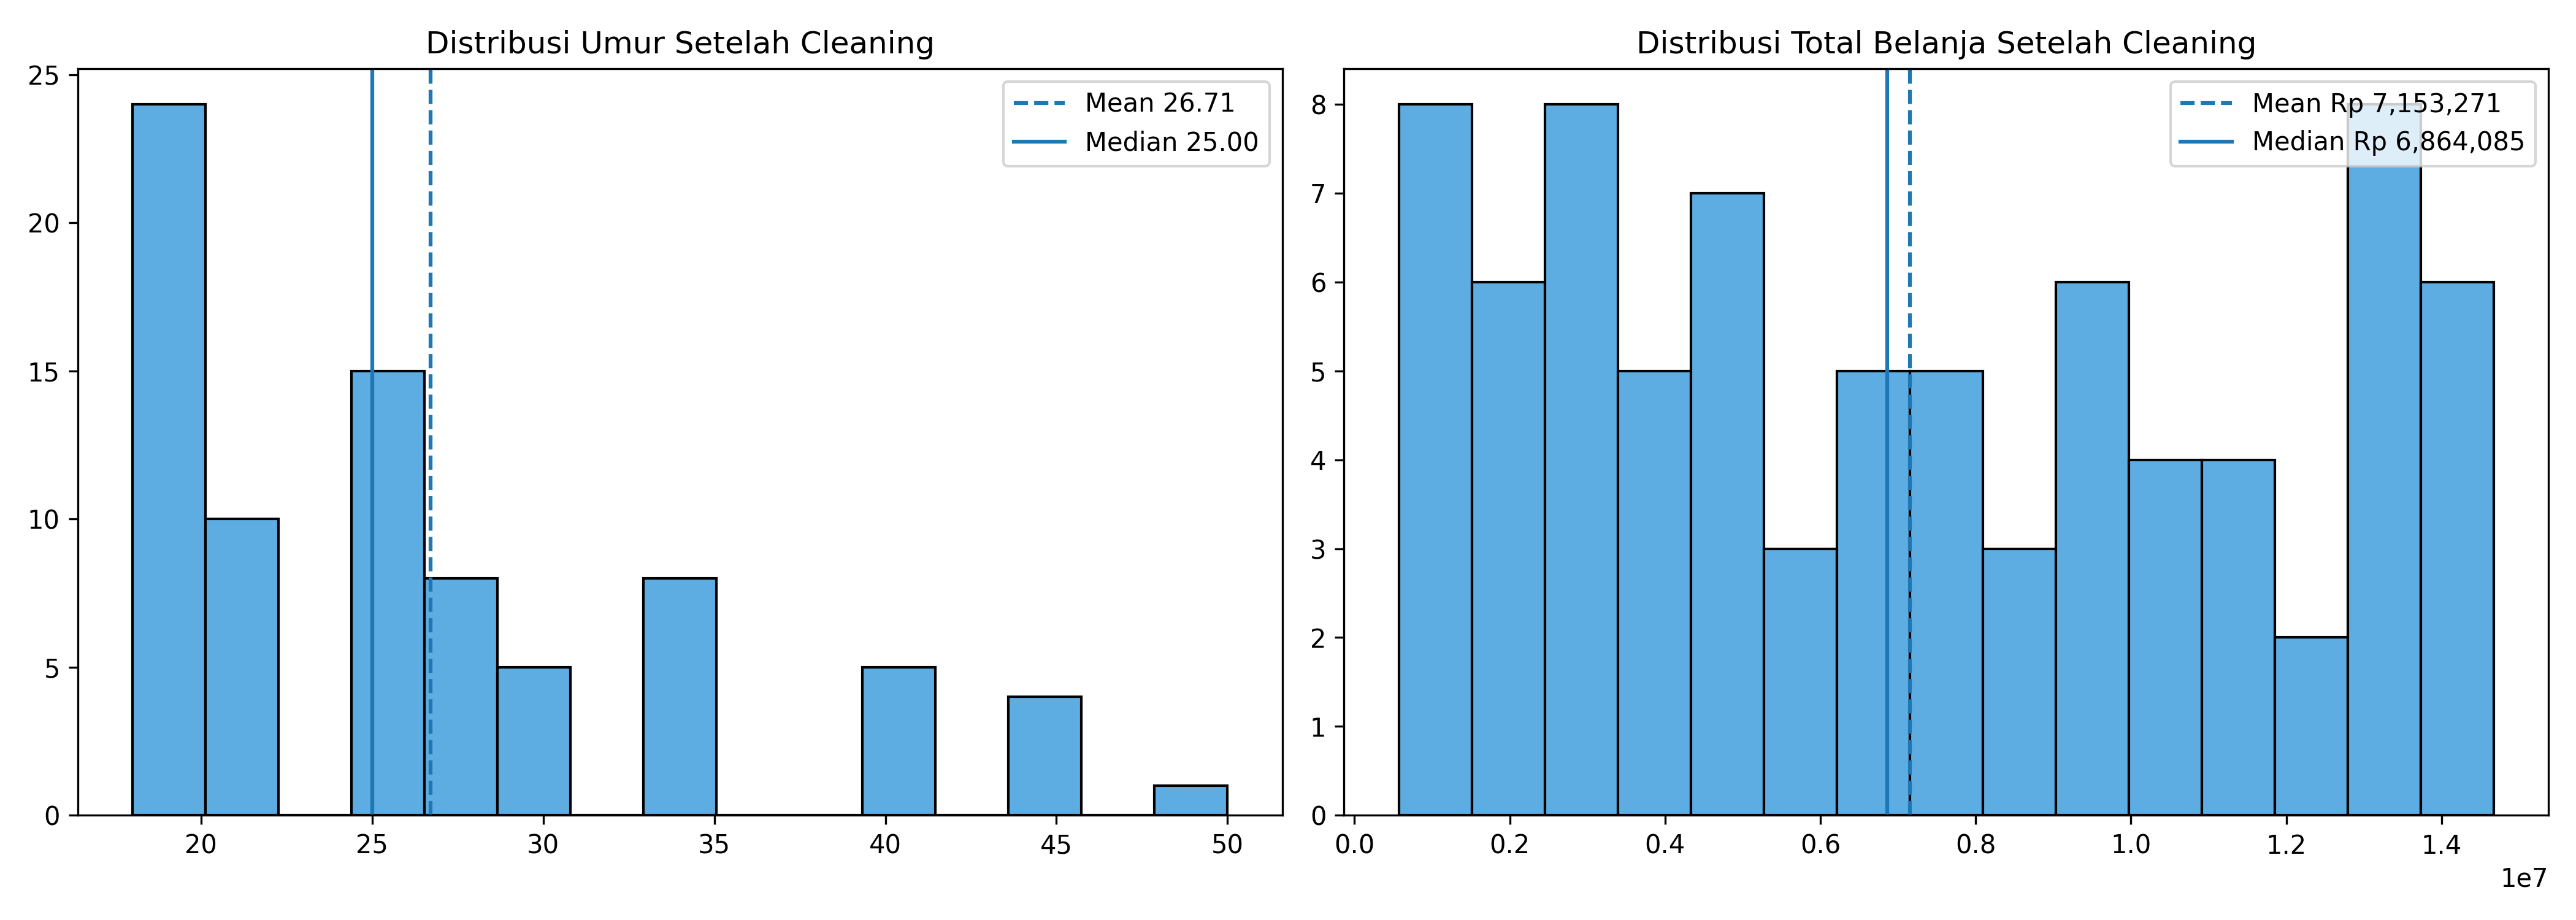

In [25]:
print("\n=== DISTRIBUSI DATA SETELAH CLEANING ===")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


mean_umur = df['Umur'].mean()
median_umur = df['Umur'].median()

mean_belanja = df['Total_Belanja'].mean()
median_belanja = df['Total_Belanja'].median()



axes[0].hist(
    df['Umur'],
    bins=15,
    edgecolor='black',
    alpha=0.7
)

axes[0].axvline(
    mean_umur,
    linestyle='--',
    linewidth=2,
    label=f'Mean = {mean_umur:.2f}'
)

axes[0].axvline(
    median_umur,
    linestyle='-',
    linewidth=2,
    label=f'Median = {median_umur:.2f}'
)


axes[0].set_title(
    'Distribusi Umur Pelanggan Setelah Cleaning',
    fontsize=12,
    fontweight='bold'
)

axes[0].set_xlabel('Umur')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()



axes[1].hist(
    df['Total_Belanja'],
    bins=15,
    edgecolor='black',
    alpha=0.7
)


axes[1].axvline(
    mean_belanja,
    linestyle='--',
    linewidth=2,
    label=f'Mean = Rp {mean_belanja:,.0f}'
)

axes[1].axvline(
    median_belanja,
    linestyle='-',
    linewidth=2,
    label=f'Median = Rp {median_belanja:,.0f}'
)


axes[1].set_title(
    'Distribusi Total Belanja Setelah Cleaning',
    fontsize=12,
    fontweight='bold'
)

axes[1].set_xlabel('Total Belanja (Rp)')
axes[1].set_ylabel('Frekuensi')
axes[1].legend()


plt.tight_layout()


plt.savefig(
    'distribusi_setelah_cleaning.png',
    dpi=300,
    bbox_inches='tight'
)


plt.show()

## 8. Temuan Utama (Insights) & Rekomendasi Bisnis

**Temuan Utama:**
1. Distribusi `Total_Belanja` bersifat *right-skewed* — mayoritas pelanggan berbelanja dalam nominal menengah ke bawah, sementara segelintir pelanggan dengan belanja sangat besar menarik rata-rata ke atas. Ini adalah pola khas *Pareto* (80/20) pada perilaku belanja pelanggan.
2. Jakarta dan Surabaya, sebagai kota besar, menyumbang porsi pendapatan yang signifikan dibanding kota lain — sejalan dengan asumsi bahwa kota besar memiliki daya beli dan intensitas transaksi online yang lebih tinggi.
3. Ditemukan sejumlah kecil data duplikat pada `ID_Pelanggan`, yang bila tidak ditangani akan menggandakan perhitungan pendapatan dan bisa menyesatkan pengambilan keputusan.

**Rekomendasi Tindakan:**
Toko dapat meningkatkan promosi, memberikan penawaran khusus, atau membuat program loyalitas pada wilayah yang memiliki transaksi tinggi. 
Pelanggan dengan total belanja di atas Rp5.000.000 dapat diberikan perlakuan khusus berupa pemberian voucher, program membership, promo eksklusif, serta rekomendasi produk yang disesuaikan dengan riwayat pembelian mereka. Selain itu, kota dengan nilai transaksi yang lebih kecil perlu dianalisis lebih lanjut untuk mengetahui faktor penyebab rendahnya tingkat pembelian, seperti kurang optimalnya strategi promosi, perbedaan preferensi produk, atau jumlah pelanggan yang masih terbatas. Hasil evaluasi tersebut dapat menjadi dasar dalam menyusun strategi pemasaran yang lebih tepat untuk meningkatkan transaksi di wilayah tersebut.
